# 07 - Heterophily - when neighbours *disagree*

GCN's whole premise is **homophily**: neighbours share your label, so averaging them
helps. Many important graphs are the opposite - **heterophilous / disassortative** -
where neighbours tend to be the *other* class: fraudsters transacting with victims,
predator-prey links, certain molecular bonds, dating networks.

When you average heterophilous neighbours, you blend the classes together and **destroy**
the signal. Let's watch vanilla GCN fail, and see what fixes it.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## GCN fails where an edge-blind MLP doesn't

On a 2-class disassortative graph (`homophily=0.2`: most edges go between classes), we
compare an MLP (ignores edges), GCN, SAGE, and GATv2. The tell: **GCN can underperform
even the MLP**, because averaging opposite-class neighbours actively corrupts features.

edge homophily = 0.21  (neighbours are mostly the OTHER class)


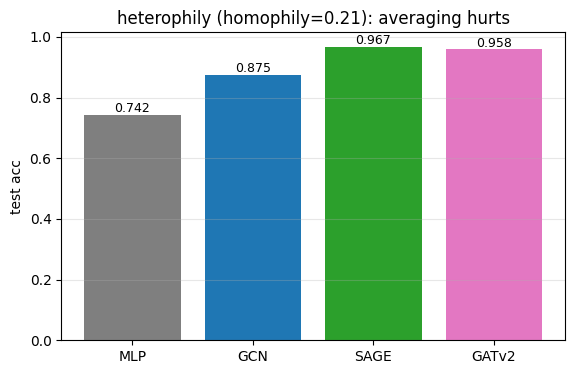

In [2]:
data, gt = G.make_heterophilous_graph(n_per_block=300, homophily=0.2, feature_signal=0.7, seed=1)
print(f"edge homophily = {gt.homophily:.2f}  (neighbours are mostly the OTHER class)")
C = int(data.y.max())+1

res = {}
for name, conv in [("MLP", None), ("GCN", "gcn"), ("SAGE", "sage"), ("GATv2", "gatv2")]:
    T.set_seed(0)
    m = (M.MLP(data.num_features, 32, C) if conv is None
         else M.GNN(data.num_features, 32, C, conv=conv, n_layers=2))
    res[name] = T.train_node(m, data, task="classification", epochs=200)
fig, ax = plt.subplots(figsize=(6.5,4))
P.bar_compare(res, title=f"heterophily (homophily={gt.homophily:.2f}): averaging hurts", ylabel="test acc", ax=ax)
plt.show()

## The fix: separate **ego** (node's own features) from **neighbours**, and use **2-hop**

Heterophily-aware GNNs (H2GCN, GPR-GNN, ...) share two ideas:

1. **Don't mix the node with its neighbours** - keep the ego embedding separate (SAGE
   already does this, which is why it survives above).
2. **Use higher-order neighbourhoods**: in a disassortative graph your *2-hop* neighbours
   tend to be your *own* class again. Aggregating 1-hop **and** 2-hop and concatenating
   recovers the signal.

Here's a minimal Heterophily-aware Higher-order Graph Convolutional Network (H2GCN) - style model built from those two ideas.

H2GCN-style test acc = 0.917


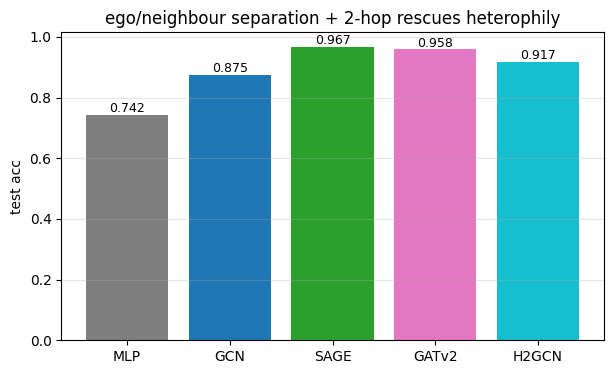

In [3]:
import torch.nn as nn, torch.nn.functional as Fnn

def nmean(h, ei):
    src, dst = ei
    agg = torch.zeros_like(h).index_add_(0, dst, h[src])
    deg = torch.zeros(h.size(0)).index_add_(0, dst, torch.ones(dst.size(0)))
    return agg / deg.clamp_min(1).unsqueeze(1)

class H2GCN(nn.Module):
    """Concatenate [ego, 1-hop mean, 2-hop mean] - separation + higher-order."""
    def __init__(self, ind, hid, outd):
        super().__init__()
        self.embed = nn.Linear(ind, hid)
        self.head  = nn.Linear(hid*3, outd)
    def forward(self, x, ei):
        h  = Fnn.relu(self.embed(x))
        h1 = nmean(h, ei)               # 1-hop (mostly opposite class)
        h2 = nmean(h1, ei)              # 2-hop (mostly same class again)
        return self.head(torch.cat([h, h1, h2], dim=1))

T.set_seed(0)
r = T.train_node(H2GCN(data.num_features, 32, C), data, task="classification", epochs=200)
res["H2GCN"] = r
print(f"H2GCN-style test acc = {r['test_metric']:.3f}")
fig, ax = plt.subplots(figsize=(7,4))
P.bar_compare(res, title="ego/neighbour separation + 2-hop rescues heterophily", ylabel="test acc", ax=ax)
plt.show()

## When to suspect heterophily (and what to do)

- **Always measure edge homophily first** (`G.homophily_ratio`). If it's well below the
  "random" baseline, vanilla GCN is the wrong tool.
- (+) Reach for **ego/neighbour separation** (SAGE) and **heterophily-aware** models
  (H2GCN, GPR-GNN, FAGCN, ...); consider **signed/higher-order** aggregation.
- (!) On strongly heterophilous graphs, sometimes a **plain MLP on features** is a
  startlingly strong baseline - a humbling reminder to always include it.

Next: **graph transformers** - drop the locality assumption entirely and let every node
attend to every other, with the **positional encodings** that make it work.